# VARIANT 03 — Pharmacy Stock-Out Risk Prediction and Daily Medicine Demand Forecasting

## Classification Task
Pharmacy Stock-Out Risk Prediction

## Forecasting Task
Daily Medicine Demand Forecasting

This notebook performs:
1. Exploratory data analysis
2. Data cleaning and validation
3. Feature preprocessing
4. Classification using Random Forest
5. Probability-based classification with threshold adjustment
6. Hyperparameter tuning
7. Seven-day medicine demand forecasting

In [1]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ============================================================
# CELL 3 — LOAD DATASETS
# ============================================================

classification_file = "P03_pharmacy_stockout_risk.csv"
forecasting_file = "P03_daily_medicine_demand.csv"

classification_df = pd.read_csv(classification_file)
forecast_df = pd.read_csv(forecasting_file)

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [3]:
# ============================================================
# CLASSIFICATION DATASET — INITIAL INSPECTION
# ============================================================

print("First 5 rows of the classification dataset:")
display(classification_df.head())

print("\nLast 5 rows:")
display(classification_df.tail())

print("\nDataset dimensions:")
print(f"Rows    : {classification_df.shape[0]}")
print(f"Columns : {classification_df.shape[1]}")

print("\nColumn names:")
print(classification_df.columns.tolist())

print("\nData types:")
display(classification_df.dtypes)

First 5 rows of the classification dataset:


,Medicine_ID,Current_Stock_Units,Average_Daily_Demand,Supplier_Lead_Time_Days,Medicine_Category,Critical_Medicine,Pending_Order_Units,Unit_Cost_PHP,Stock_Out_Risk
0,MED-0000,58.0,5.0,4,Type B,No,16,652.78,No
1,MED-0001,68.0,14.3,7,Type A,No,5,52.93,Yes
2,MED-0002,56.0,13.4,4,Type A,No,19,521.55,No
3,MED-0003,87.0,12.7,5,Type B,Yes,12,315.96,No
4,MED-0004,61.0,14.4,2,Type C,Yes,77,494.46,No



Last 5 rows:


,Medicine_ID,Current_Stock_Units,Average_Daily_Demand,Supplier_Lead_Time_Days,Medicine_Category,Critical_Medicine,Pending_Order_Units,Unit_Cost_PHP,Stock_Out_Risk
475,MED-0475,72.0,22.1,5,Type B,No,16,734.41,Yes
476,MED-0476,86.0,10.6,6,Type C,Yes,52,180.59,No
477,MED-0477,68.0,26.0,7,Type A,Yes,9,NaN,No
478,MED-0478,124.0,8.7,5,Type B,Yes,41,564.93,Yes
479,MED-0479,91.0,14.2,5,Type B,No,33,874.15,No



Dataset dimensions:
Rows    : 480
Columns : 9

Column names:
['Medicine_ID', 'Current_Stock_Units', 'Average_Daily_Demand', 'Supplier_Lead_Time_Days', 'Medicine_Category', 'Critical_Medicine', 'Pending_Order_Units', 'Unit_Cost_PHP', 'Stock_Out_Risk']

Data types:


Medicine_ID                    str
Current_Stock_Units        float64
Average_Daily_Demand       float64
Supplier_Lead_Time_Days      int64
Medicine_Category              str
Critical_Medicine              str
Pending_Order_Units          int64
Unit_Cost_PHP              float64
Stock_Out_Risk                 str
dtype: object

In [4]:
# ============================================================
# MISSING-VALUE SUMMARY
# ============================================================

missing_summary = pd.DataFrame({
    "Missing Count": classification_df.isnull().sum(),
    "Missing Percentage": (
        classification_df.isnull().mean() * 100
    ).round(2)
})

display(missing_summary)

,Missing Count,Missing Percentage
Medicine_ID,0,0.00
Current_Stock_Units,0,0.00
Average_Daily_Demand,8,1.67
Supplier_Lead_Time_Days,0,0.00
Medicine_Category,8,1.67
Critical_Medicine,0,0.00
Pending_Order_Units,0,0.00
Unit_Cost_PHP,8,1.67
Stock_Out_Risk,0,0.00


In [5]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

print("Numerical descriptive statistics:")
display(classification_df.describe())

print("\nAll-column descriptive statistics:")
display(classification_df.describe(include="all"))

Numerical descriptive statistics:


,Current_Stock_Units,Average_Daily_Demand,Supplier_Lead_Time_Days,Pending_Order_Units,Unit_Cost_PHP
count,480.000000,472.000000,480.000000,480.00000,472.000000
mean,80.564583,15.227119,4.895833,38.37500,469.903983
std,26.116249,10.355582,1.639028,22.91158,253.044873
min,36.000000,3.900000,2.000000,0.00000,25.040000
25%,61.000000,9.300000,4.000000,18.75000,255.002500
50%,80.000000,13.700000,5.000000,38.00000,478.865000
75%,98.000000,18.125000,6.000000,59.00000,687.817500
max,169.000000,128.000000,10.000000,79.00000,898.700000



All-column descriptive statistics:


,Medicine_ID,Current_Stock_Units,Average_Daily_Demand,Supplier_Lead_Time_Days,Medicine_Category,Critical_Medicine,Pending_Order_Units,Unit_Cost_PHP,Stock_Out_Risk
count,480,480.000000,472.000000,480.000000,472,480,480.00000,472.000000,480
unique,480,NaN,NaN,NaN,3,2,NaN,NaN,2
top,MED-0000,NaN,NaN,NaN,Type A,No,NaN,NaN,No
freq,1,NaN,NaN,NaN,163,255,NaN,NaN,317
mean,NaN,80.564583,15.227119,4.895833,NaN,NaN,38.37500,469.903983,NaN
std,NaN,26.116249,10.355582,1.639028,NaN,NaN,22.91158,253.044873,NaN
min,NaN,36.000000,3.900000,2.000000,NaN,NaN,0.00000,25.040000,NaN
25%,NaN,61.000000,9.300000,4.000000,NaN,NaN,18.75000,255.002500,NaN
50%,NaN,80.000000,13.700000,5.000000,NaN,NaN,38.00000,478.865000,NaN
75%,NaN,98.000000,18.125000,6.000000,NaN,NaN,59.00000,687.817500,NaN


Target value counts:


Stock_Out_Risk
No     317
Yes    163
Name: count, dtype: int64


Target percentages:


Stock_Out_Risk
No     66.04
Yes    33.96
Name: proportion, dtype: float64

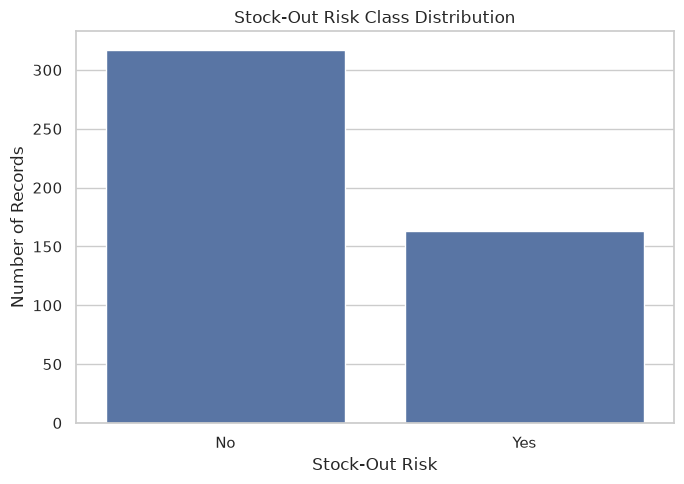

In [6]:
# ============================================================
# TARGET / CLASS DISTRIBUTION
# ============================================================

target_column = "Stock_Out_Risk"

print("Target value counts:")
display(classification_df[target_column].value_counts())

print("\nTarget percentages:")
display(
    (classification_df[target_column].value_counts(normalize=True) * 100)
    .round(2)
)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=classification_df,
    x=target_column
)

plt.title("Stock-Out Risk Class Distribution")
plt.xlabel("Stock-Out Risk")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

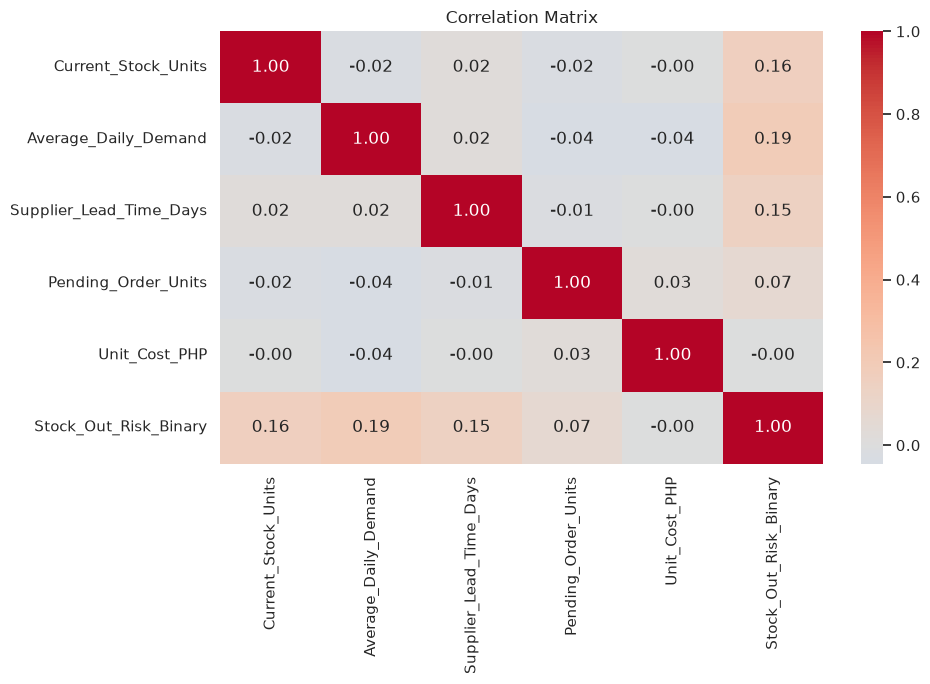

In [7]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

# Temporarily convert the target to binary for correlation analysis
correlation_df = classification_df.copy()

correlation_df["Stock_Out_Risk_Binary"] = (
    correlation_df["Stock_Out_Risk"]
    .map({"No": 0, "Yes": 1})
)

numeric_correlation = correlation_df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_correlation.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

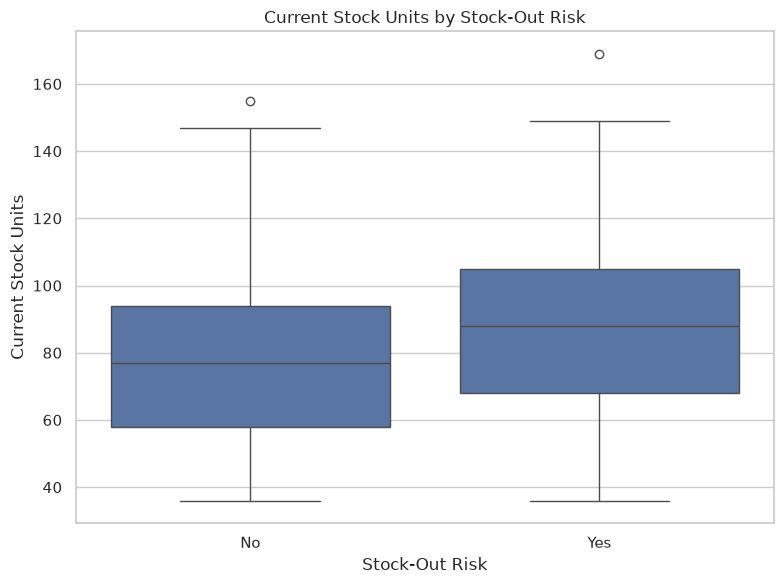

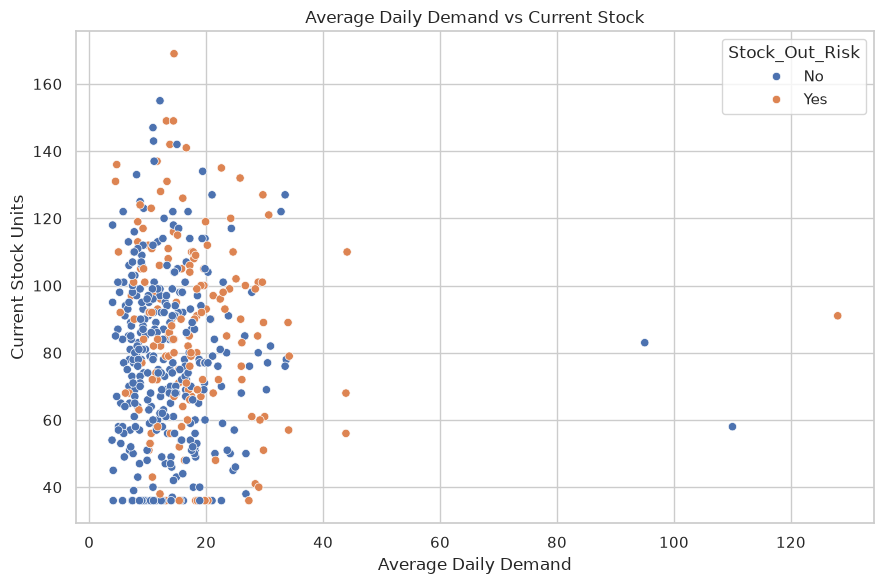

In [8]:
# ============================================================
# RELATIONSHIP BETWEEN STOCK AND STOCK-OUT RISK
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=classification_df,
    x="Stock_Out_Risk",
    y="Current_Stock_Units"
)

plt.title("Current Stock Units by Stock-Out Risk")
plt.xlabel("Stock-Out Risk")
plt.ylabel("Current Stock Units")

plt.tight_layout()
plt.show()
# ============================================================
# DEMAND VS CURRENT STOCK
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=classification_df,
    x="Average_Daily_Demand",
    y="Current_Stock_Units",
    hue="Stock_Out_Risk"
)

plt.title("Average Daily Demand vs Current Stock")
plt.xlabel("Average Daily Demand")
plt.ylabel("Current Stock Units")

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# DUPLICATE INVESTIGATION
# ============================================================

duplicate_count = classification_df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    display(classification_df[classification_df.duplicated()])
else:
    print("No duplicate rows were found.")

Number of duplicate rows: 0
No duplicate rows were found.


In [10]:
# ============================================================
# INVALID-VALUE INVESTIGATION
# ============================================================

numeric_columns = [
    "Current_Stock_Units",
    "Average_Daily_Demand",
    "Supplier_Lead_Time_Days",
    "Pending_Order_Units",
    "Unit_Cost_PHP"
]

print("Negative values by numerical column:")

for column in numeric_columns:
    negative_count = (classification_df[column] < 0).sum()
    print(f"{column}: {negative_count}")
print("\nZero values by numerical column:")

for column in numeric_columns:
    zero_count = (classification_df[column] == 0).sum()
    print(f"{column}: {zero_count}")

Negative values by numerical column:
Current_Stock_Units: 0
Average_Daily_Demand: 0
Supplier_Lead_Time_Days: 0
Pending_Order_Units: 0
Unit_Cost_PHP: 0

Zero values by numerical column:
Current_Stock_Units: 0
Average_Daily_Demand: 0
Supplier_Lead_Time_Days: 0
Pending_Order_Units: 3
Unit_Cost_PHP: 0


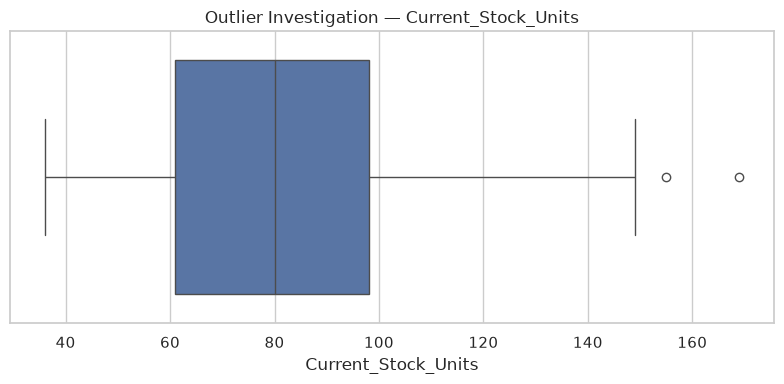

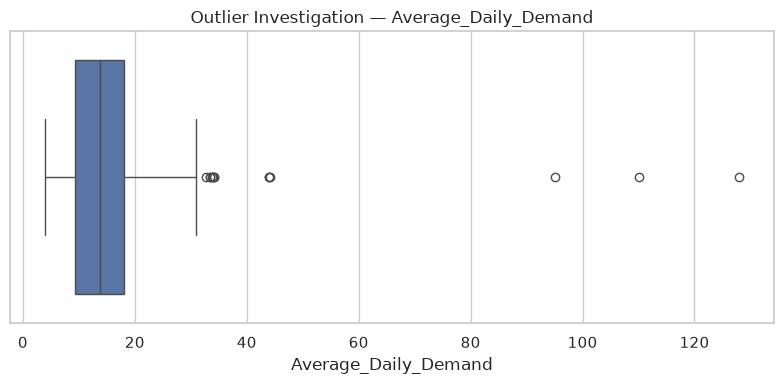

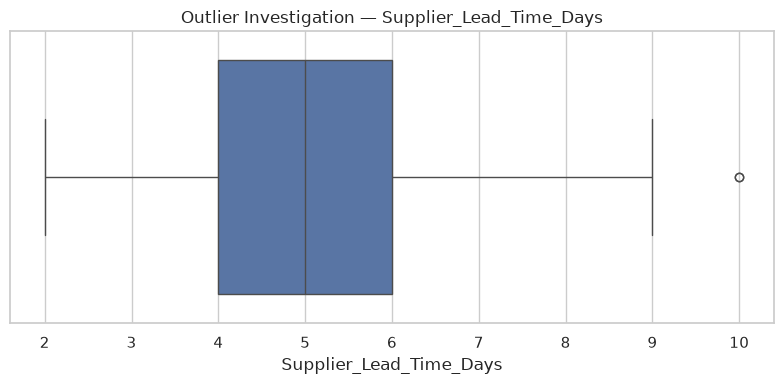

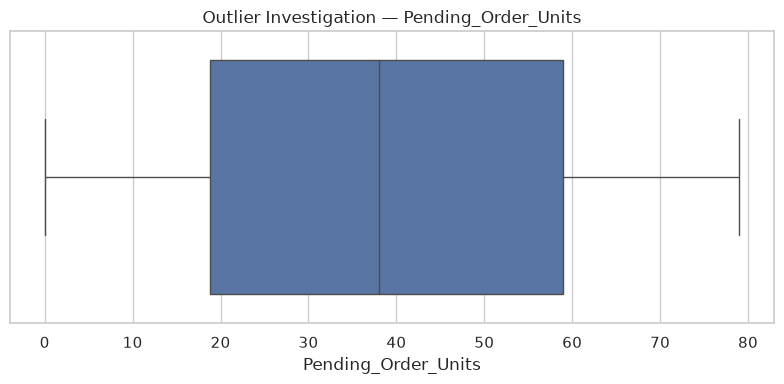

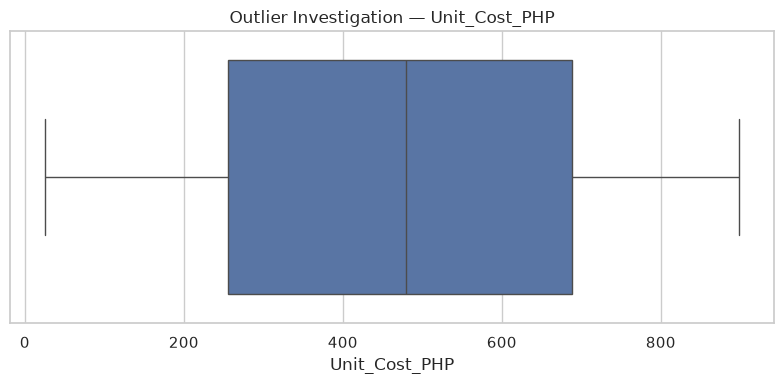

In [12]:
# ============================================================
# OUTLIER INVESTIGATION
# ============================================================

for column in numeric_columns:
    
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        x=classification_df[column]
    )
    
    plt.title(f"Outlier Investigation — {column}")
    plt.xlabel(column)
    
    plt.tight_layout()
    plt.show()


In [13]:
# ============================================================
# IQR OUTLIER COUNTS
# ============================================================

def count_iqr_outliers(dataframe, column):
    
    series = dataframe[column].dropna()
    
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]
    
    return len(outliers), lower_bound, upper_bound


outlier_results = []

for column in numeric_columns:
    
    count, lower, upper = count_iqr_outliers(
        classification_df,
        column
    )
    
    outlier_results.append({
        "Column": column,
        "Outlier Count": count,
        "Lower Bound": lower,
        "Upper Bound": upper
    })

outlier_df = pd.DataFrame(outlier_results)

display(outlier_df)

,Column,Outlier Count,Lower Bound,Upper Bound
0,Current_Stock_Units,2,5.5000,153.5000
1,Average_Daily_Demand,13,-3.9375,31.3625
2,Supplier_Lead_Time_Days,2,1.0000,9.0000
3,Pending_Order_Units,0,-41.6250,119.3750
4,Unit_Cost_PHP,0,-394.2200,1337.0400


### Outlier Interpretation

Outliers were investigated using boxplots and the IQR method. Outliers were not automatically deleted because unusually high medicine demand, stock levels, or costs can represent legitimate pharmacy conditions. Instead, the values were reviewed and retained unless they were determined to be invalid.

The machine-learning preprocessing pipeline handles missing numerical values using median imputation.

In [14]:
# ============================================================
# FEATURE PREPARATION
# ============================================================

target_column = "Stock_Out_Risk"

X = classification_df.drop(columns=[target_column])

y = classification_df[target_column]

# Remove identifier because it is unique to each medicine record
X = X.drop(columns=["Medicine_ID"])

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Current_Stock_Units', 'Average_Daily_Demand', 'Supplier_Lead_Time_Days', 'Medicine_Category', 'Critical_Medicine', 'Pending_Order_Units', 'Unit_Cost_PHP']

Target:
Stock_Out_Risk


In [15]:
# ============================================================
# IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
for feature in numeric_features:
    print(" -", feature)

print("\nCategorical features:")
for feature in categorical_features:
    print(" -", feature)

Numerical features:
 - Current_Stock_Units
 - Average_Daily_Demand
 - Supplier_Lead_Time_Days
 - Pending_Order_Units
 - Unit_Cost_PHP

Categorical features:
 - Medicine_Category
 - Critical_Medicine


In [16]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training dimensions:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting dimensions:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training dimensions:
X_train: (384, 7)
y_train: (384,)

Testing dimensions:
X_test: (96, 7)
y_test: (96,)


In [17]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [18]:
# ============================================================
# ORIGINAL CLASSIFICATION MODEL
# ============================================================

original_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

original_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", original_model)
    ]
)

original_pipeline.fit(
    X_train,
    y_train
)

print("Original Random Forest model trained successfully.")

Original Random Forest model trained successfully.


In [19]:
# ============================================================
# TEST PREDICTIONS
# ============================================================

y_pred = original_pipeline.predict(X_test)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
['No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No'
 'No' 'No' 'No' 'No' 'No' 'Yes']


In [20]:
# ============================================================
# CLASSIFICATION PERFORMANCE
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    pos_label="Yes",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label="Yes",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Yes",
    zero_division=0
)

print("Original Random Forest Performance")
print("-----------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Original Random Forest Performance
-----------------------------------
Accuracy : 0.6146
Precision: 0.4091
Recall   : 0.2727
F1-score : 0.3273


In [21]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

          No       0.68      0.79      0.73        63
         Yes       0.41      0.27      0.33        33

    accuracy                           0.61        96
   macro avg       0.54      0.53      0.53        96
weighted avg       0.58      0.61      0.59        96



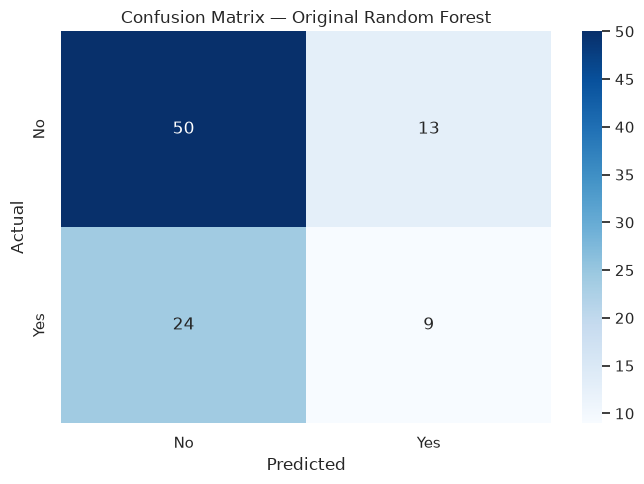

In [22]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Confusion Matrix — Original Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# PREDICTION PROBABILITIES
# ============================================================

probabilities = original_pipeline.predict_proba(X_test)

model_classes = original_pipeline.classes_

print("Model classes:")
print(model_classes)

print("\nProbability columns correspond to:")
print(model_classes)

yes_index = list(model_classes).index("Yes")

yes_probability = probabilities[:, yes_index]

probability_output = pd.DataFrame({
    "Actual": y_test.values,
    "Probability_of_Stockout_Risk": yes_probability,
    "Default_Prediction": y_pred
})

display(
    probability_output.head(15)
)

Model classes:
['No' 'Yes']

Probability columns correspond to:
['No' 'Yes']


,Actual,Probability_of_Stockout_Risk,Default_Prediction
0,No,0.215,No
1,Yes,0.270,No
2,No,0.450,No
3,No,0.145,No
4,No,0.165,No
5,No,0.630,Yes
6,No,0.420,No
7,No,0.295,No
8,Yes,0.435,No
9,Yes,0.460,No


In [24]:
# ============================================================
# MODIFIED DECISION THRESHOLD
# ============================================================

default_threshold = 0.50
modified_threshold = 0.30

y_pred_modified = np.where(
    yes_probability >= modified_threshold,
    "Yes",
    "No"
)

print(f"Default threshold : {default_threshold}")
print(f"Modified threshold: {modified_threshold}")

print("\nModified predictions:")
print(pd.Series(y_pred_modified).value_counts())

Default threshold : 0.5
Modified threshold: 0.3

Modified predictions:
Yes    61
No     35
Name: count, dtype: int64


In [25]:
# ============================================================
# THRESHOLD PERFORMANCE COMPARISON
# ============================================================

modified_accuracy = accuracy_score(
    y_test,
    y_pred_modified
)

modified_precision = precision_score(
    y_test,
    y_pred_modified,
    pos_label="Yes",
    zero_division=0
)

modified_recall = recall_score(
    y_test,
    y_pred_modified,
    pos_label="Yes",
    zero_division=0
)

modified_f1 = f1_score(
    y_test,
    y_pred_modified,
    pos_label="Yes",
    zero_division=0
)

threshold_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Default Threshold (0.50)": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Modified Threshold (0.30)": [
        modified_accuracy,
        modified_precision,
        modified_recall,
        modified_f1
    ]
})

display(
    threshold_comparison.round(4)
)

,Metric,Default Threshold (0.50),Modified Threshold (0.30)
0,Accuracy,0.6146,0.5000
1,Precision,0.4091,0.3770
2,Recall,0.2727,0.6970
3,F1-score,0.3273,0.4894


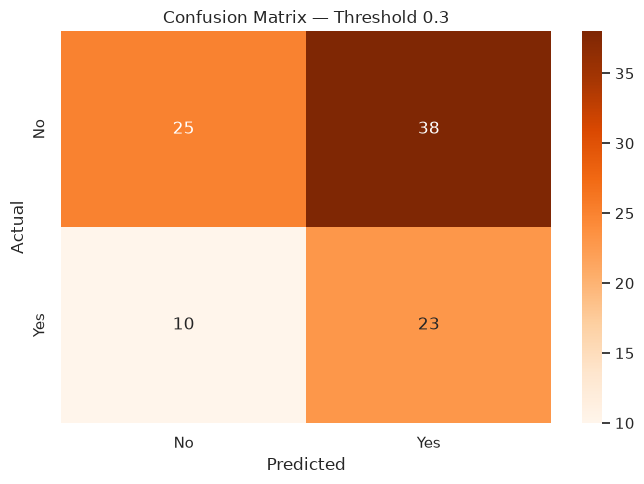

In [26]:
# ============================================================
# MODIFIED THRESHOLD CONFUSION MATRIX
# ============================================================

cm_modified = confusion_matrix(
    y_test,
    y_pred_modified,
    labels=["No", "Yes"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_modified,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title(
    f"Confusion Matrix — Threshold {modified_threshold}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### Threshold Interpretation

The default classification threshold is 0.50. A modified threshold of 0.30 was also tested.

Lowering the threshold means that the model requires less probability before classifying a medicine as being at risk of stock-out. This generally makes the classifier more sensitive to possible stock-out cases, which can increase recall, while potentially increasing false positives and reducing precision.

The default and modified threshold results are compared using accuracy, precision, recall, and F1-score rather than relying on accuracy alone.

In [27]:
# ============================================================
# TUNED RANDOM FOREST
# ============================================================

tuned_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

tuned_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", tuned_model)
    ]
)

tuned_pipeline.fit(
    X_train,
    y_train
)

print("Tuned Random Forest model trained successfully.")

Tuned Random Forest model trained successfully.


In [28]:
# ============================================================
# TUNED MODEL PREDICTIONS
# ============================================================

y_pred_tuned = tuned_pipeline.predict(
    X_test
)

print("First 20 tuned predictions:")
print(y_pred_tuned[:20])

First 20 tuned predictions:
['No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No'
 'No' 'No' 'No' 'No' 'No' 'Yes']


In [29]:
# ============================================================
# TUNED MODEL PERFORMANCE
# ============================================================

tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned,
    pos_label="Yes",
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned,
    pos_label="Yes",
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    pos_label="Yes",
    zero_division=0
)

print("Tuned Random Forest Performance")
print("--------------------------------")
print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1-score : {tuned_f1:.4f}")

Tuned Random Forest Performance
--------------------------------
Accuracy : 0.6354
Precision: 0.4500
Recall   : 0.2727
F1-score : 0.3396


In [30]:
# ============================================================
# ORIGINAL VS TUNED MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Original Random Forest": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Tuned Random Forest": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

display(
    model_comparison.round(4)
)

,Metric,Original Random Forest,Tuned Random Forest
0,Accuracy,0.6146,0.6354
1,Precision,0.4091,0.4500
2,Recall,0.2727,0.2727
3,F1-score,0.3273,0.3396


In [31]:
# ============================================================
# FINAL MODEL SELECTION
# ============================================================

if tuned_f1 > f1:
    selected_model_name = "Tuned Random Forest"
    selected_model = tuned_pipeline
    selected_f1 = tuned_f1
else:
    selected_model_name = "Original Random Forest"
    selected_model = original_pipeline
    selected_f1 = f1

print("Final Model Selection")
print("=====================")
print(f"Selected model: {selected_model_name}")
print(f"Selected F1-score: {selected_f1:.4f}")

Final Model Selection
Selected model: Tuned Random Forest
Selected F1-score: 0.3396


# Part C — Daily Medicine Demand Forecasting

The second dataset contains daily medicine demand observations. The objective is to prepare the time series chronologically and forecast medicine demand for the next seven days.

In [32]:
# ============================================================
# FORECASTING DATASET — INITIAL INSPECTION
# ============================================================

print("First 10 rows:")
display(forecast_df.head(10))

print("\nDimensions:")
print(f"Rows    : {forecast_df.shape[0]}")
print(f"Columns : {forecast_df.shape[1]}")

print("\nColumn names:")
print(forecast_df.columns.tolist())

print("\nData types:")
display(forecast_df.dtypes)

print("\nMissing values:")
display(forecast_df.isnull().sum())

First 10 rows:


,Date,Medicine_Demand_Units
0,2026-01-01,428.0
1,2026-01-02,466.0
2,2026-01-03,474.0
3,2026-01-04,447.0
4,2026-01-05,411.0
5,2026-01-06,389.0
6,2026-01-07,398.0
7,2026-01-08,434.0
8,2026-01-09,466.0
9,2026-01-10,479.0



Dimensions:
Rows    : 180
Columns : 2

Column names:
['Date', 'Medicine_Demand_Units']

Data types:


Date                         str
Medicine_Demand_Units    float64
dtype: object


Missing values:


Date                     0
Medicine_Demand_Units    3
dtype: int64

In [33]:
# ============================================================
# DATE CONVERSION
# ============================================================

forecast_df["Date"] = pd.to_datetime(
    forecast_df["Date"],
    errors="coerce"
)

invalid_dates = forecast_df["Date"].isna().sum()

print(f"Invalid dates after conversion: {invalid_dates}")

Invalid dates after conversion: 0


In [34]:
# ============================================================
# MISSING DEMAND HANDLING
# ============================================================

print(
    "Missing demand values before treatment:",
    forecast_df["Medicine_Demand_Units"].isna().sum()
)

# Linear interpolation is appropriate for isolated missing observations
forecast_df["Medicine_Demand_Units"] = (
    forecast_df["Medicine_Demand_Units"]
    .interpolate(method="linear")
    .ffill()
    .bfill()
)

print(
    "Missing demand values after treatment:",
    forecast_df["Medicine_Demand_Units"].isna().sum()
)

Missing demand values before treatment: 3
Missing demand values after treatment: 0


In [35]:
# ============================================================
# CHRONOLOGICAL PREPARATION
# ============================================================

forecast_df = (
    forecast_df
    .sort_values("Date")
    .reset_index(drop=True)
)

print("Date range:")
print("Start:", forecast_df["Date"].min())
print("End  :", forecast_df["Date"].max())

print("\nChronologically sorted data:")
display(forecast_df.head())

Date range:
Start: 2026-01-01 00:00:00
End  : 2026-06-29 00:00:00

Chronologically sorted data:


,Date,Medicine_Demand_Units
0,2026-01-01,428.0
1,2026-01-02,466.0
2,2026-01-03,474.0
3,2026-01-04,447.0
4,2026-01-05,411.0


In [36]:
# ============================================================
# CHECK FOR DUPLICATE DATES
# ============================================================

duplicate_dates = forecast_df["Date"].duplicated().sum()

print(f"Duplicate dates: {duplicate_dates}")

if duplicate_dates > 0:
    display(
        forecast_df[
            forecast_df["Date"].duplicated(keep=False)
        ]
    )
else:
    print("No duplicate dates found.")

Duplicate dates: 0
No duplicate dates found.


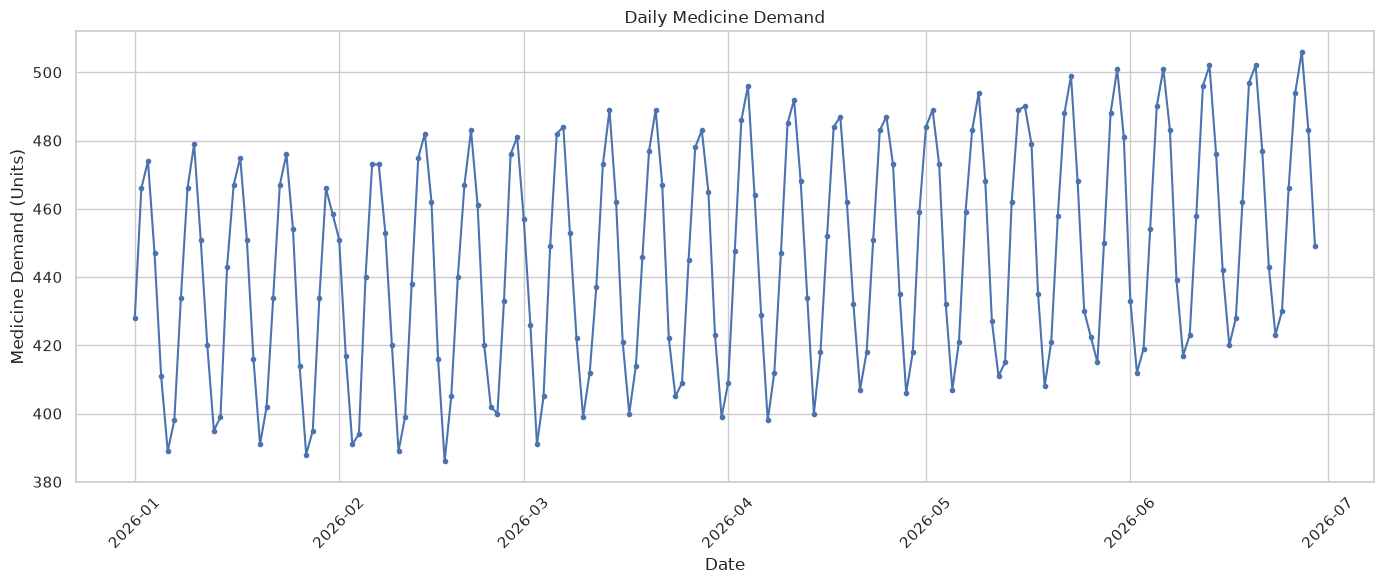

In [37]:
# ============================================================
# TIME-SERIES VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_df["Date"],
    forecast_df["Medicine_Demand_Units"],
    marker="o",
    markersize=3
)

plt.title("Daily Medicine Demand")
plt.xlabel("Date")
plt.ylabel("Medicine Demand (Units)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

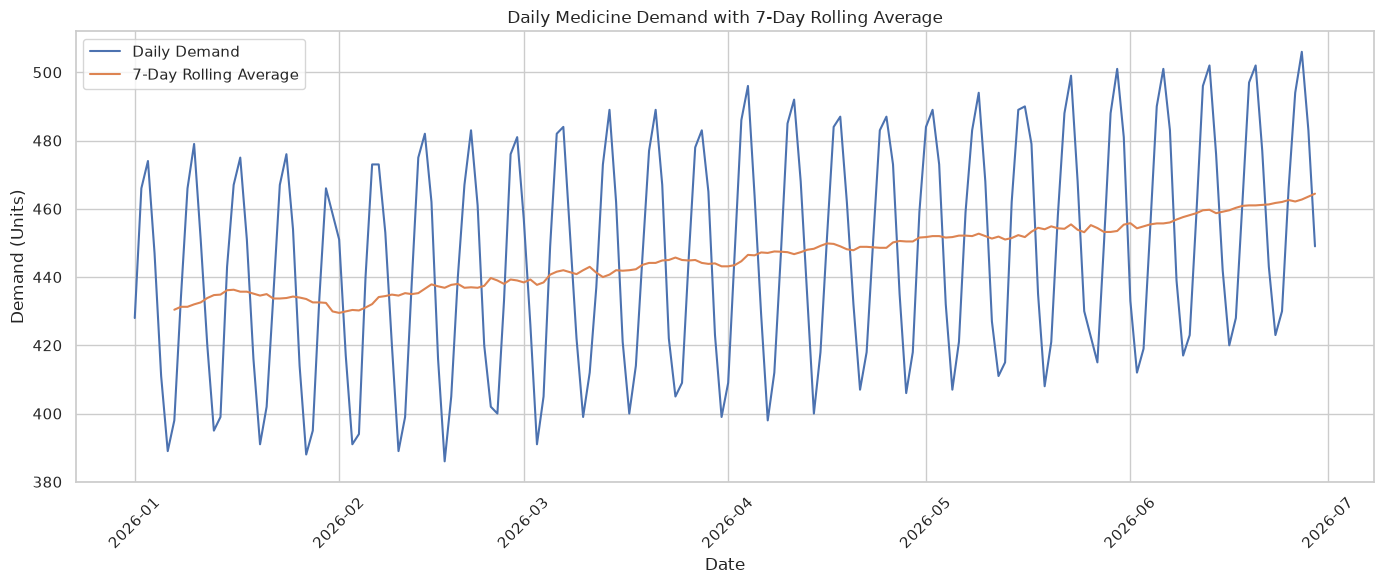

In [38]:
# ============================================================
# 7-DAY ROLLING AVERAGE
# ============================================================

forecast_df["7_Day_Rolling_Average"] = (
    forecast_df["Medicine_Demand_Units"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_df["Date"],
    forecast_df["Medicine_Demand_Units"],
    label="Daily Demand"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["7_Day_Rolling_Average"],
    label="7-Day Rolling Average"
)

plt.title("Daily Medicine Demand with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Demand (Units)")
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# FORECASTING VALIDATION SPLIT
# ============================================================

forecast_series = (
    forecast_df
    .set_index("Date")["Medicine_Demand_Units"]
)

validation_days = 7

train_series = forecast_series.iloc[:-validation_days]
validation_series = forecast_series.iloc[-validation_days:]

print("Training observations:", len(train_series))
print("Validation observations:", len(validation_series))

print("\nTraining period:")
print(train_series.index.min(), "to", train_series.index.max())

print("\nValidation period:")
print(validation_series.index.min(), "to", validation_series.index.max())

Training observations: 173
Validation observations: 7

Training period:
2026-01-01 00:00:00 to 2026-06-22 00:00:00

Validation period:
2026-06-23 00:00:00 to 2026-06-29 00:00:00


In [40]:
# ============================================================
# HOLT-WINTERS FORECASTING MODEL
# ============================================================

validation_model = ExponentialSmoothing(
    train_series,
    trend="add",
    seasonal="add",
    seasonal_periods=7
)

validation_fitted = validation_model.fit(
    optimized=True
)

print("Holt-Winters model trained successfully.")

Holt-Winters model trained successfully.


/home/beatriceoira/Variant03/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [41]:
# ============================================================
# VALIDATION FORECAST
# ============================================================

validation_prediction = validation_fitted.forecast(
    validation_days
)

validation_results = pd.DataFrame({
    "Date": validation_series.index,
    "Actual": validation_series.values,
    "Predicted": validation_prediction.values
})

display(validation_results)

,Date,Actual,Predicted
0,2026-06-23,423.0,417.078484
1,2026-06-24,430.0,426.057272
2,2026-06-25,466.0,462.730633
3,2026-06-26,494.0,495.750246
4,2026-06-27,506.0,502.970146
5,2026-06-28,483.0,480.550592
6,2026-06-29,449.0,442.670219


In [42]:
# ============================================================
# FORECASTING VALIDATION METRICS
# ============================================================

mae = mean_absolute_error(
    validation_series,
    validation_prediction
)

rmse = np.sqrt(
    mean_squared_error(
        validation_series,
        validation_prediction
    )
)

print("Forecasting Validation Performance")
print("-----------------------------------")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Forecasting Validation Performance
-----------------------------------
MAE : 3.81
RMSE: 4.13


### Forecasting Model Interpretation

The forecasting model was evaluated using a chronological holdout consisting of the final seven observed days. Mean Absolute Error (MAE) measures the average absolute forecasting error in demand units, while Root Mean Squared Error (RMSE) gives greater weight to larger errors.

The validation results provide an indication of how accurately the model can forecast unseen future demand while preserving the temporal ordering of the observations.

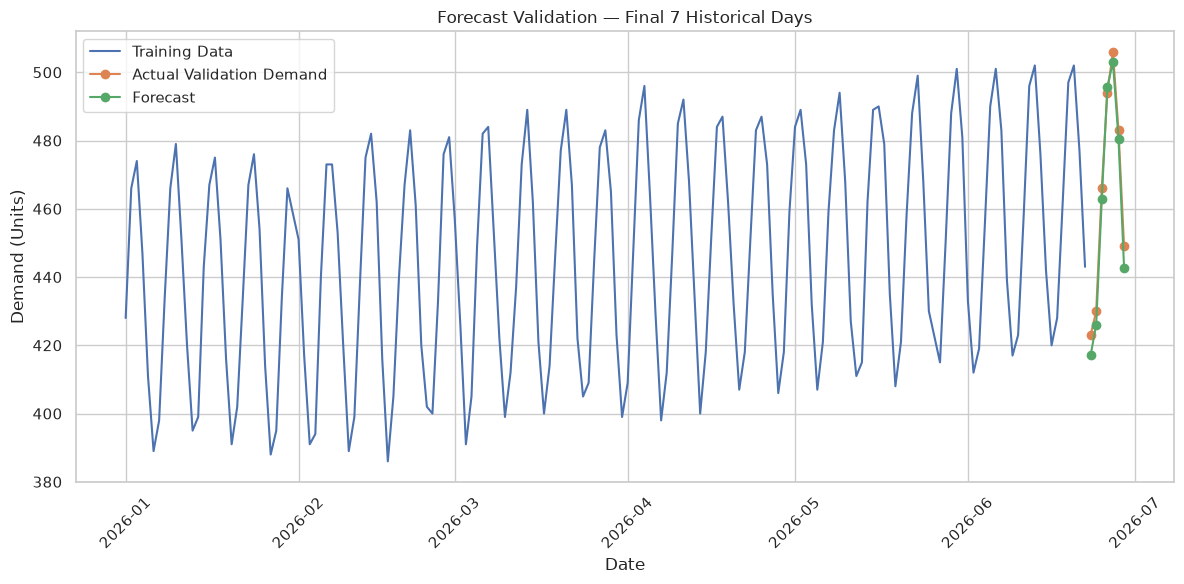

In [43]:
# ============================================================
# VALIDATION VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    train_series.index,
    train_series.values,
    label="Training Data"
)

plt.plot(
    validation_series.index,
    validation_series.values,
    marker="o",
    label="Actual Validation Demand"
)

plt.plot(
    validation_prediction.index,
    validation_prediction.values,
    marker="o",
    label="Forecast"
)

plt.title("Forecast Validation — Final 7 Historical Days")
plt.xlabel("Date")
plt.ylabel("Demand (Units)")
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [44]:
# ============================================================
# FINAL FORECASTING MODEL
# ============================================================

final_forecast_model = ExponentialSmoothing(
    forecast_series,
    trend="add",
    seasonal="add",
    seasonal_periods=7
)

final_forecast_fitted = final_forecast_model.fit(
    optimized=True
)

print("Final forecasting model trained using all available data.")

Final forecasting model trained using all available data.


/home/beatriceoira/Variant03/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [45]:
# ============================================================
# 7-DAY FUTURE FORECAST
# ============================================================

forecast_horizon = 7

future_forecast = final_forecast_fitted.forecast(
    forecast_horizon
)

print("7-Day Forecast:")
display(future_forecast)

7-Day Forecast:


2026-06-30    418.943607
2026-07-01    427.843400
2026-07-02    464.499173
2026-07-03    497.325581
2026-07-04    504.729438
2026-07-05    482.287661
2026-07-06    444.556372
Freq: D, dtype: float64

In [46]:
# ============================================================
# FINAL FORECAST TABLE
# ============================================================

final_forecast_table = pd.DataFrame({
    "Future Period": future_forecast.index,
    "Forecasted Value": future_forecast.values
})

final_forecast_table["Forecasted Value"] = (
    final_forecast_table["Forecasted Value"]
    .round(2)
)

display(final_forecast_table)

,Future Period,Forecasted Value
0,2026-06-30,418.94
1,2026-07-01,427.84
2,2026-07-02,464.50
3,2026-07-03,497.33
4,2026-07-04,504.73
5,2026-07-05,482.29
6,2026-07-06,444.56


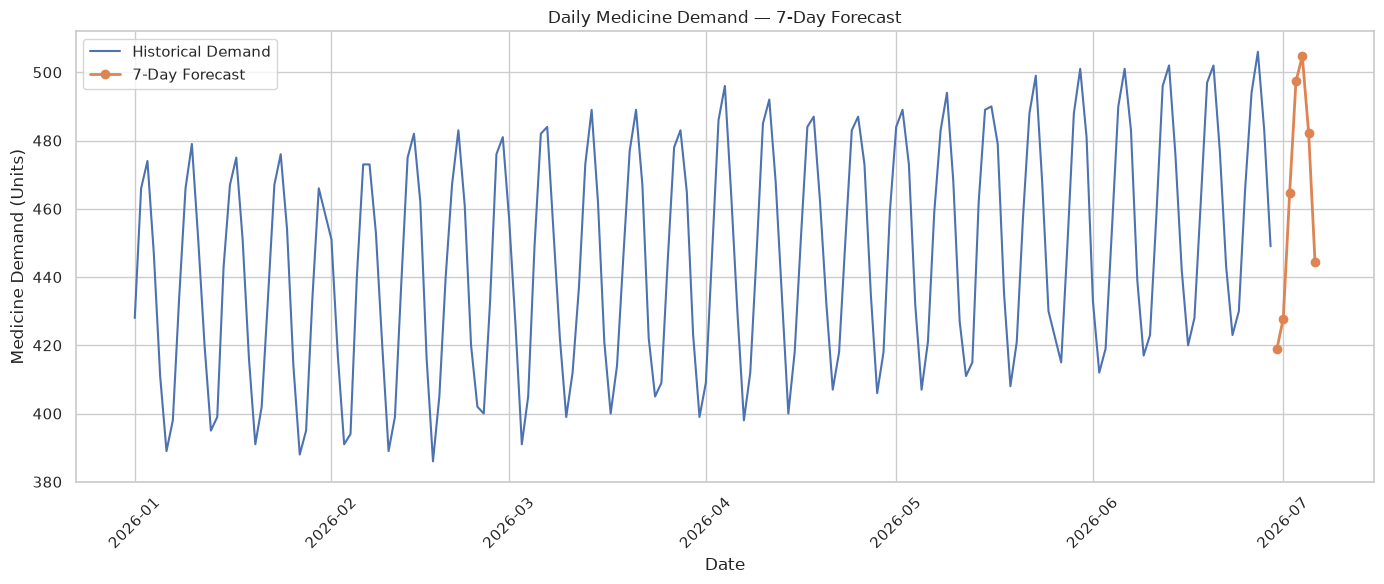

In [47]:
# ============================================================
# FINAL 7-DAY FORECAST VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_series.index,
    forecast_series.values,
    label="Historical Demand"
)

plt.plot(
    future_forecast.index,
    future_forecast.values,
    marker="o",
    linewidth=2,
    label="7-Day Forecast"
)

plt.title("Daily Medicine Demand — 7-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Medicine Demand (Units)")
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Final Forecast Interpretation

The final Holt-Winters model was trained using the complete chronological demand dataset. A seven-day forecast was then generated for the periods immediately following the final observed date.

The forecasting results provide estimated medicine demand for each future day. The model incorporates both the overall demand trend and the observed weekly seasonal pattern. These forecasts can be used as estimates for short-term inventory and replenishment planning.

In [ ]:
# Final Summary

## Classification

The pharmacy stock-out classification task was completed using a Random Forest classifier. The dataset was inspected for missing values, invalid values, duplicates, and potential outliers. `Medicine_ID` was removed because it functions as an identifier rather than a meaningful predictive feature. Numerical missing values were handled using median imputation, while categorical missing values were handled using the most frequent category. Categorical variables were encoded using one-hot encoding.

The original model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. Prediction probabilities were also generated, allowing a modified decision threshold of 0.30 to be evaluated against the default threshold of 0.50. A tuned Random Forest with modified hyperparameters was then compared against the original model, and the final model was selected based on the observed test-set performance.

## Forecasting

The daily medicine demand dataset was converted to a proper datetime format, checked for invalid and duplicate dates, sorted chronologically, and processed for missing demand values. The demand series was visualized to identify its overall pattern and weekly behavior.

A Holt-Winters exponential smoothing model with a seven-day seasonal period was evaluated using the final seven historical observations as a chronological validation set. MAE and RMSE were calculated to measure forecasting error. Finally, the model was retrained using the complete historical dataset and used to generate the required seven-day medicine demand forecast.

The final forecast table presents the future period and corresponding forecasted medicine demand.